In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


# Import Libraries

Importing all necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Data Loading

Loading the Training and Test Datasets

In [4]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv')

In [5]:
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape: (10000, 17)
Test shape:  (1500, 17)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


The training dataset has **10000 rows, 17 columns**

The test dataset has **1500 rows, 17 columns**

# Data Types 
**Rubric task 1:** Identify data types of different columns

In [6]:
print("=== DATA TYPES ===")
print(train_df.info())
print("\n=== COLUMN CATEGORIES ===")
print("Numerical columns: ", train_df.select_dtypes(include=['int64','float64']).columns.tolist())
print("Categorical columns: ", train_df.select_dtypes(include=['object']).columns.tolist())

=== DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-nul

There are **13 Numerical** (3 integer and 10 float) features and **4 Categorical** features in our dataset along with **1 target variable: total_amount**.

# Descriptive Statistics
**Rubric Task 2:** Present descriptive statistics of numerical columns

In [7]:
desc = train_df.describe().T
desc['median'] = train_df.median(numeric_only=True)
desc

,count,mean,std,min,25%,50%,75%,max,median
VendorID,10000.0,0.729100,0.444672,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000
passenger_count,9634.0,1.357276,0.883676,0.000000,1.000000,1.000000,1.000000,6.000000,1.000000
trip_distance,10000.0,3.679527,4.905798,0.000000,1.070000,1.820000,3.630000,71.940000,1.820000
RatecodeID,9634.0,1.450695,5.988978,1.000000,1.000000,1.000000,1.000000,99.000000,1.000000
PULocationID,10000.0,132.710800,75.789597,1.000000,67.000000,133.000000,198.000000,264.000000,133.000000
DOLocationID,10000.0,132.332400,75.959440,1.000000,68.000000,132.000000,199.000000,264.000000,132.000000
extra,10000.0,1.940950,1.945885,-7.500000,0.000000,1.750000,2.500000,11.750000,1.750000
tip_amount,10000.0,6.094658,4.438894,0.000713,3.466789,5.208233,7.455228,84.032617,5.208233
tolls_amount,10000.0,0.664425,2.441070,-26.550000,0.000000,0.000000,0.000000,32.050000,0.000000
improvement_surcharge,10000.0,0.979490,0.200076,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Summary Analysis

- **Missing Values:**  
  Some columns have fewer than 10,000 observations (`passenger_count`, `RatecodeID`, `congestion_surcharge`, `Airport_fee`), indicating missing values.

- **Passenger Count:**  
  Median = 1, suggesting most trips involve a single passenger. Maximum is 6.

- **Trip Distance:**  
  Highly skewed. Median = 1.82 miles while max = 71.94 miles, indicating a few very long trips.

- **RatecodeID:**  
  Most values are 1 (median = 1), but the maximum of 99 suggests possible outliers or special codes.

- **Location IDs:**  
  `PULocationID` and `DOLocationID` are widely distributed (1–264), indicating trips across many zones.

- **Extra Charges:**  
  `extra` and `tolls_amount` contain negative values, which may represent adjustments or refunds.

- **Tips:**  
  Median tip ≈ 5.21, with some very high values (max ≈ 84), suggesting occasional large tips.

- **Total Amount:**  
  Strong right skew: median ≈ 21.36 but maximum = 551, indicating extreme fare outliers.

- **Surcharges:**  
  `congestion_surcharge` is mostly fixed at 2.5, and `improvement_surcharge` is almost always 1.

- **Airport Fee:**  
  Mostly 0, meaning only a small subset of trips involve airports.

# Feature Engineering 
Raw datetimes can't be fed to models. **Extracting hour/day/duration** helps us create more useful predictive features
Also, initital data exploration showed us that there are many rows that contain pickup time that comes after drop off time. This results in a **negative total duration**. To fix this, we perform a **swap to fix** the likely error of wrong input time.


In [8]:
def fix_timestamps(df):
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    
    mask = df['tpep_pickup_datetime'] > df['tpep_dropoff_datetime']
    
    temp_pickup = df.loc[mask, 'tpep_pickup_datetime']
    
    df.loc[mask, 'tpep_pickup_datetime'] = df.loc[mask, 'tpep_dropoff_datetime']
    df.loc[mask, 'tpep_dropoff_datetime'] = temp_pickup
    
    return df

train_df = fix_timestamps(train_df)
test_df = fix_timestamps(test_df)

print(f"Timestamps fixed for both sets.")

Timestamps fixed for both sets.


Further, we divide the time stamps into `duration`, `hour` and `day_of_week`

In [9]:
def preprocess(df):
    df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    df['hour'] = df['tpep_pickup_datetime'].dt.hour
    df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
    
    cols_to_drop = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)

In [10]:
print("--- Train Data Check ---")
print(train_df[['duration', 'hour', 'day_of_week']].head())

train_neg = (train_df['duration'] < 0).sum()
test_neg = (test_df['duration'] < 0).sum()

print(f"\nNegative durations in Train: {train_neg}")
print(f"Negative durations in Test: {test_neg}")

--- Train Data Check ---
    duration  hour  day_of_week
0  50.433333    17            2
1   8.400000    19            3
2  27.516667    18            4
3   2.050000    22            4
4  67.783333    17            2

Negative durations in Train: 0
Negative durations in Test: 0


- We are also creating a new variable called `speed_mph` which will capture distance covered per minute of the ride to help us overcome the duration fallacy (Short rides through city traffic vs long rides on a highway can take similar duration).

- we also include features like `is_rush_hour` and `is_overnight` to see if such factors affect the cost

In [11]:
def add_taxi_features(df):
    # 1. Speed (Distance / Duration) - helps identify traffic/highway trips
    df['speed_mph'] = df['trip_distance'] / (df['duration'] / 60 + 0.1)
    
    # 2. Rush Hour Surcharge Flag (Weekdays, 4 PM to 8 PM)
    df['is_rush_hour'] = ((df['day_of_week'] <= 5) & (df['hour'] >= 16) & (df['hour'] < 20)).astype(int)
    
    # 3. Overnight Surcharge Flag (8 PM to 6 AM)
    df['is_overnight'] = ((df['hour'] >= 20) | (df['hour'] < 6)).astype(int)
    
    return df

train_df = add_taxi_features(train_df)
test_df = add_taxi_features(test_df)

Based on intuition, We are analyzing `RatecodeID` to see if there is any pattern that emerges for each separate ratecodes.

In [12]:
ratecode_costs = train_df.groupby('RatecodeID')['total_amount'].mean().sort_values(ascending=False)
ratecode_med = train_df.groupby('RatecodeID')['total_amount'].median().sort_values(ascending=False)

print("Average Cost by RatecodeID:")
print(ratecode_costs)
print(ratecode_med)

ratecode_counts = train_df['RatecodeID'].value_counts()
print("\nTrip Counts by RatecodeID:")
print(ratecode_counts)

Average Cost by RatecodeID:
RatecodeID
4.0     150.590645
3.0     125.222069
5.0      90.869020
2.0      88.382419
99.0     37.190278
1.0      25.514901
Name: total_amount, dtype: float64
RatecodeID
4.0     140.700
3.0     130.595
2.0      92.500
5.0      85.210
99.0     32.850
1.0      20.520
Name: total_amount, dtype: float64

Trip Counts by RatecodeID:
RatecodeID
1.0     9057
2.0      401
3.0       58
5.0       51
99.0      36
4.0       31
Name: count, dtype: int64


- It is very evident that there are 3 subcategories of rides not just one, which can be classified as **cheap(1,99), medium(2,5) and premium(3,4)**. This essentially results in 3 different clusters of analysis.

In [13]:
# Tier 1: Cheap
cheap_codes = [1.0, 99.0]
train_df['is_cheap'] = train_df['RatecodeID'].isin(cheap_codes).astype(int)
test_df['is_cheap'] = test_df['RatecodeID'].isin(cheap_codes).astype(int)

# Tier 2: Medium
medium_codes = [2.0, 5.0]
train_df['is_medium'] = train_df['RatecodeID'].isin(medium_codes).astype(int)
test_df['is_medium'] = test_df['RatecodeID'].isin(medium_codes).astype(int)

# Tier 3: Premium / High-Value
premium_codes = [3.0, 4.0]
train_df['is_premium'] = train_df['RatecodeID'].isin(premium_codes).astype(int)
test_df['is_premium'] = test_df['RatecodeID'].isin(premium_codes).astype(int)

#  Identify Missing Values
**Rubric Task 3:** Identify and handle the missing values

In [14]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Percentage
passenger_count,366,3.66
RatecodeID,366,3.66
store_and_fwd_flag,366,3.66
congestion_surcharge,366,3.66
Airport_fee,366,3.66


We can see there are **5 columns that contain missing values** (4 numerical and 1 categorical).

We will replace the missing values in **numerical columns with Median** as it is robust to outliers and **categorical columns with Mode **

In [15]:
# For numerical columns
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
train_df[num_cols] = train_df[num_cols].fillna(train_df[num_cols].median())

# For categorical columns
cat_cols = train_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

print("Missing values after handling:", train_df.isnull().sum().sum())

Missing values after handling: 0


In [16]:
# Apply the same logic to test_df using TRAIN statistics
for col in num_cols:
    if col in test_df.columns:
        # Use train_df median to fill test_df
        test_df[col] = test_df[col].fillna(train_df[col].median())

for col in cat_cols:
    if col in test_df.columns:
        # Use train_df mode to fill test_df
        test_df[col] = test_df[col].fillna(train_df[col].mode()[0])

print("Missing values in Test after handling:", test_df.isnull().sum().sum())

Missing values in Test after handling: 0


#  Identify & Remove Duplicates
**Rubric Task 4:** Identify and handle duplicates

In [17]:
print("Duplicate rows found:", train_df.duplicated().sum())
train_df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", train_df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (10000, 24)


It is evident that there are **no duplicate rows** in the dataset.

# Correlation Analysis

We will now perform a correlation analysis to understand the relationships between numerical features and the target variable **total_amount**.

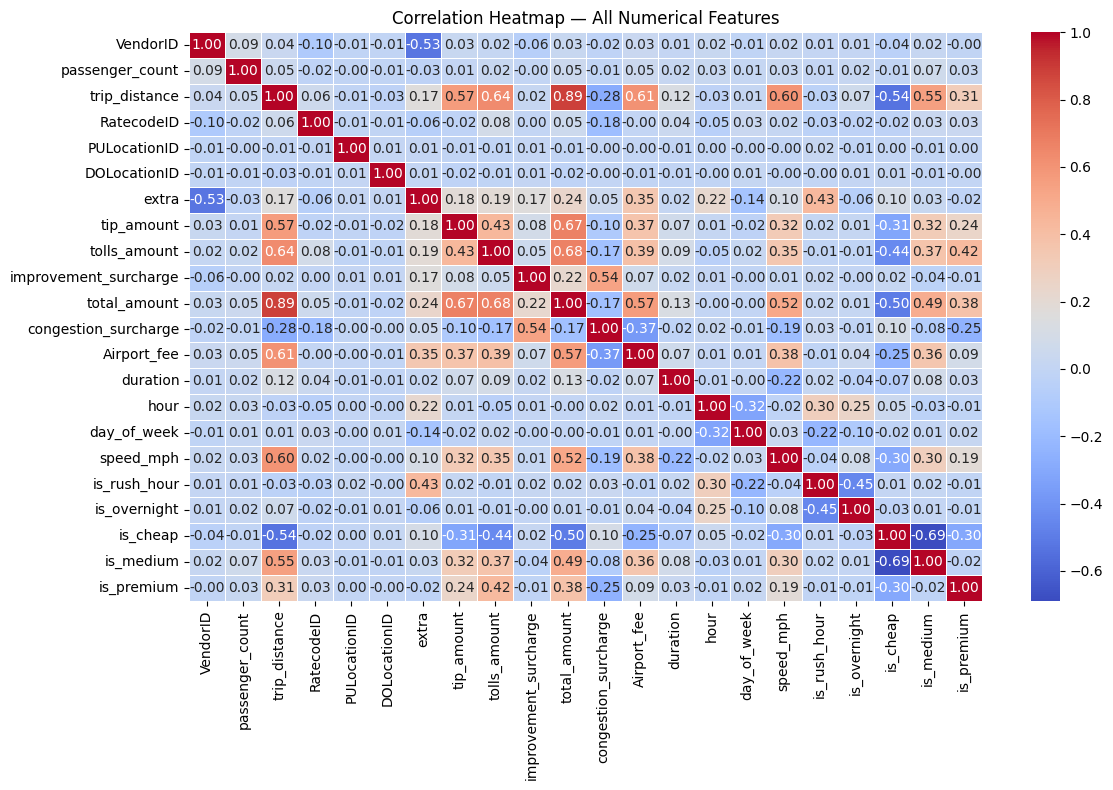

In [18]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df.select_dtypes(include=['float64', 'int64', 'int32']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Features')
plt.tight_layout()
plt.show()

In [19]:
# Print top correlations with target
print("\nTop correlations with total_amount:")
print(corr_matrix['total_amount'].sort_values(ascending=False))


Top correlations with total_amount:
total_amount             1.000000
trip_distance            0.887272
tolls_amount             0.676149
tip_amount               0.673531
Airport_fee              0.570620
speed_mph                0.515398
is_medium                0.488296
is_premium               0.376515
extra                    0.236473
improvement_surcharge    0.222112
duration                 0.126525
RatecodeID               0.054803
passenger_count          0.048409
VendorID                 0.028361
is_rush_hour             0.021957
is_overnight             0.012744
day_of_week             -0.000941
hour                    -0.001921
PULocationID            -0.007692
DOLocationID            -0.018600
congestion_surcharge    -0.172187
is_cheap                -0.503979
Name: total_amount, dtype: float64


### Correlation Analysis

#### Strongest Predictors of `total_amount`
- `trip_distance` (r = 0.887) — remains the strongest genuine predictor. Taxi fares scale primarily with distance.

#### Derived Distance Category Indicators
- `is_medium` (r = 0.488) and `is_premium` (r = 0.377) — binary indicators for ride categories provide useful segmentation of fare patterns.
- `is_cheap` (r = -0.504) — strong negative correlation because cheap rides correspond to short trips with lower fares.

#### Cost Components (Legitimate Features)
These columns are components of the fare but are **available in the test set**, so they are retained:
- `tolls_amount` (r = 0.676)
- `tip_amount` (r = 0.674)
- `Airport_fee` (r = 0.571)
- `extra` (r = 0.236)
- `improvement_surcharge` (r = 0.222)
- `congestion_surcharge` (r = -0.172)

These values directly influence the final fare and therefore show expected correlations.

#### Engineered Behavioral Feature
- `speed_mph` (r = 0.515) —  This captures traffic conditions and route type (highway vs dense city traffic). It shows stronger predictive signal than `duration` (r = 0.127) alone.

#### Weak Linear Predictors
These variables show little direct linear relationship with fare but may still help tree-based models:
- `duration` (r = 0.127) — weak because long time does not always imply long distance.
- `passenger_count` (r = 0.048)
- `RatecodeID` (r = 0.055)
- `VendorID` (r = 0.028)

#### Temporal Features
Time-based features show almost no linear relationship with fare:
- `hour` (r = -0.002)
- `day_of_week` (r ≈ 0)  

However, they may still help capture rush-hour patterns or demand spikes in nonlinear models.

#### Location Features
- `PULocationID` (r = -0.008)  
- `DOLocationID` (r = -0.019)  

Raw zone IDs show near-zero correlation. However, target encoding by average fare per zone can transform them into meaningful predictors.

#### Negative Correlations
- `is_cheap` (r = -0.504) — expected since cheap trips correspond to low fares.
- `congestion_surcharge` (r = -0.172) — congested city rides tend to be shorter and cheaper overall despite the surcharge.

#### Outlier Monitoring
Outliers are most likely in:
- `trip_distance`
- `duration`
- `speed_mph`

These variables are susceptible to GPS errors, logging issues, or extreme trips, and will be prioritized during outlier handling.


We are **retaining Weak and Negative correlations** because Tree based models might be able to find a relation between multiple varibales which linear models might not be able to catch

# Outlier Detection & Handling
**Rubric Task 5:** Identify and handle outliers

We use the **IQR (Interquartile Range) method** to detect outliers:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1

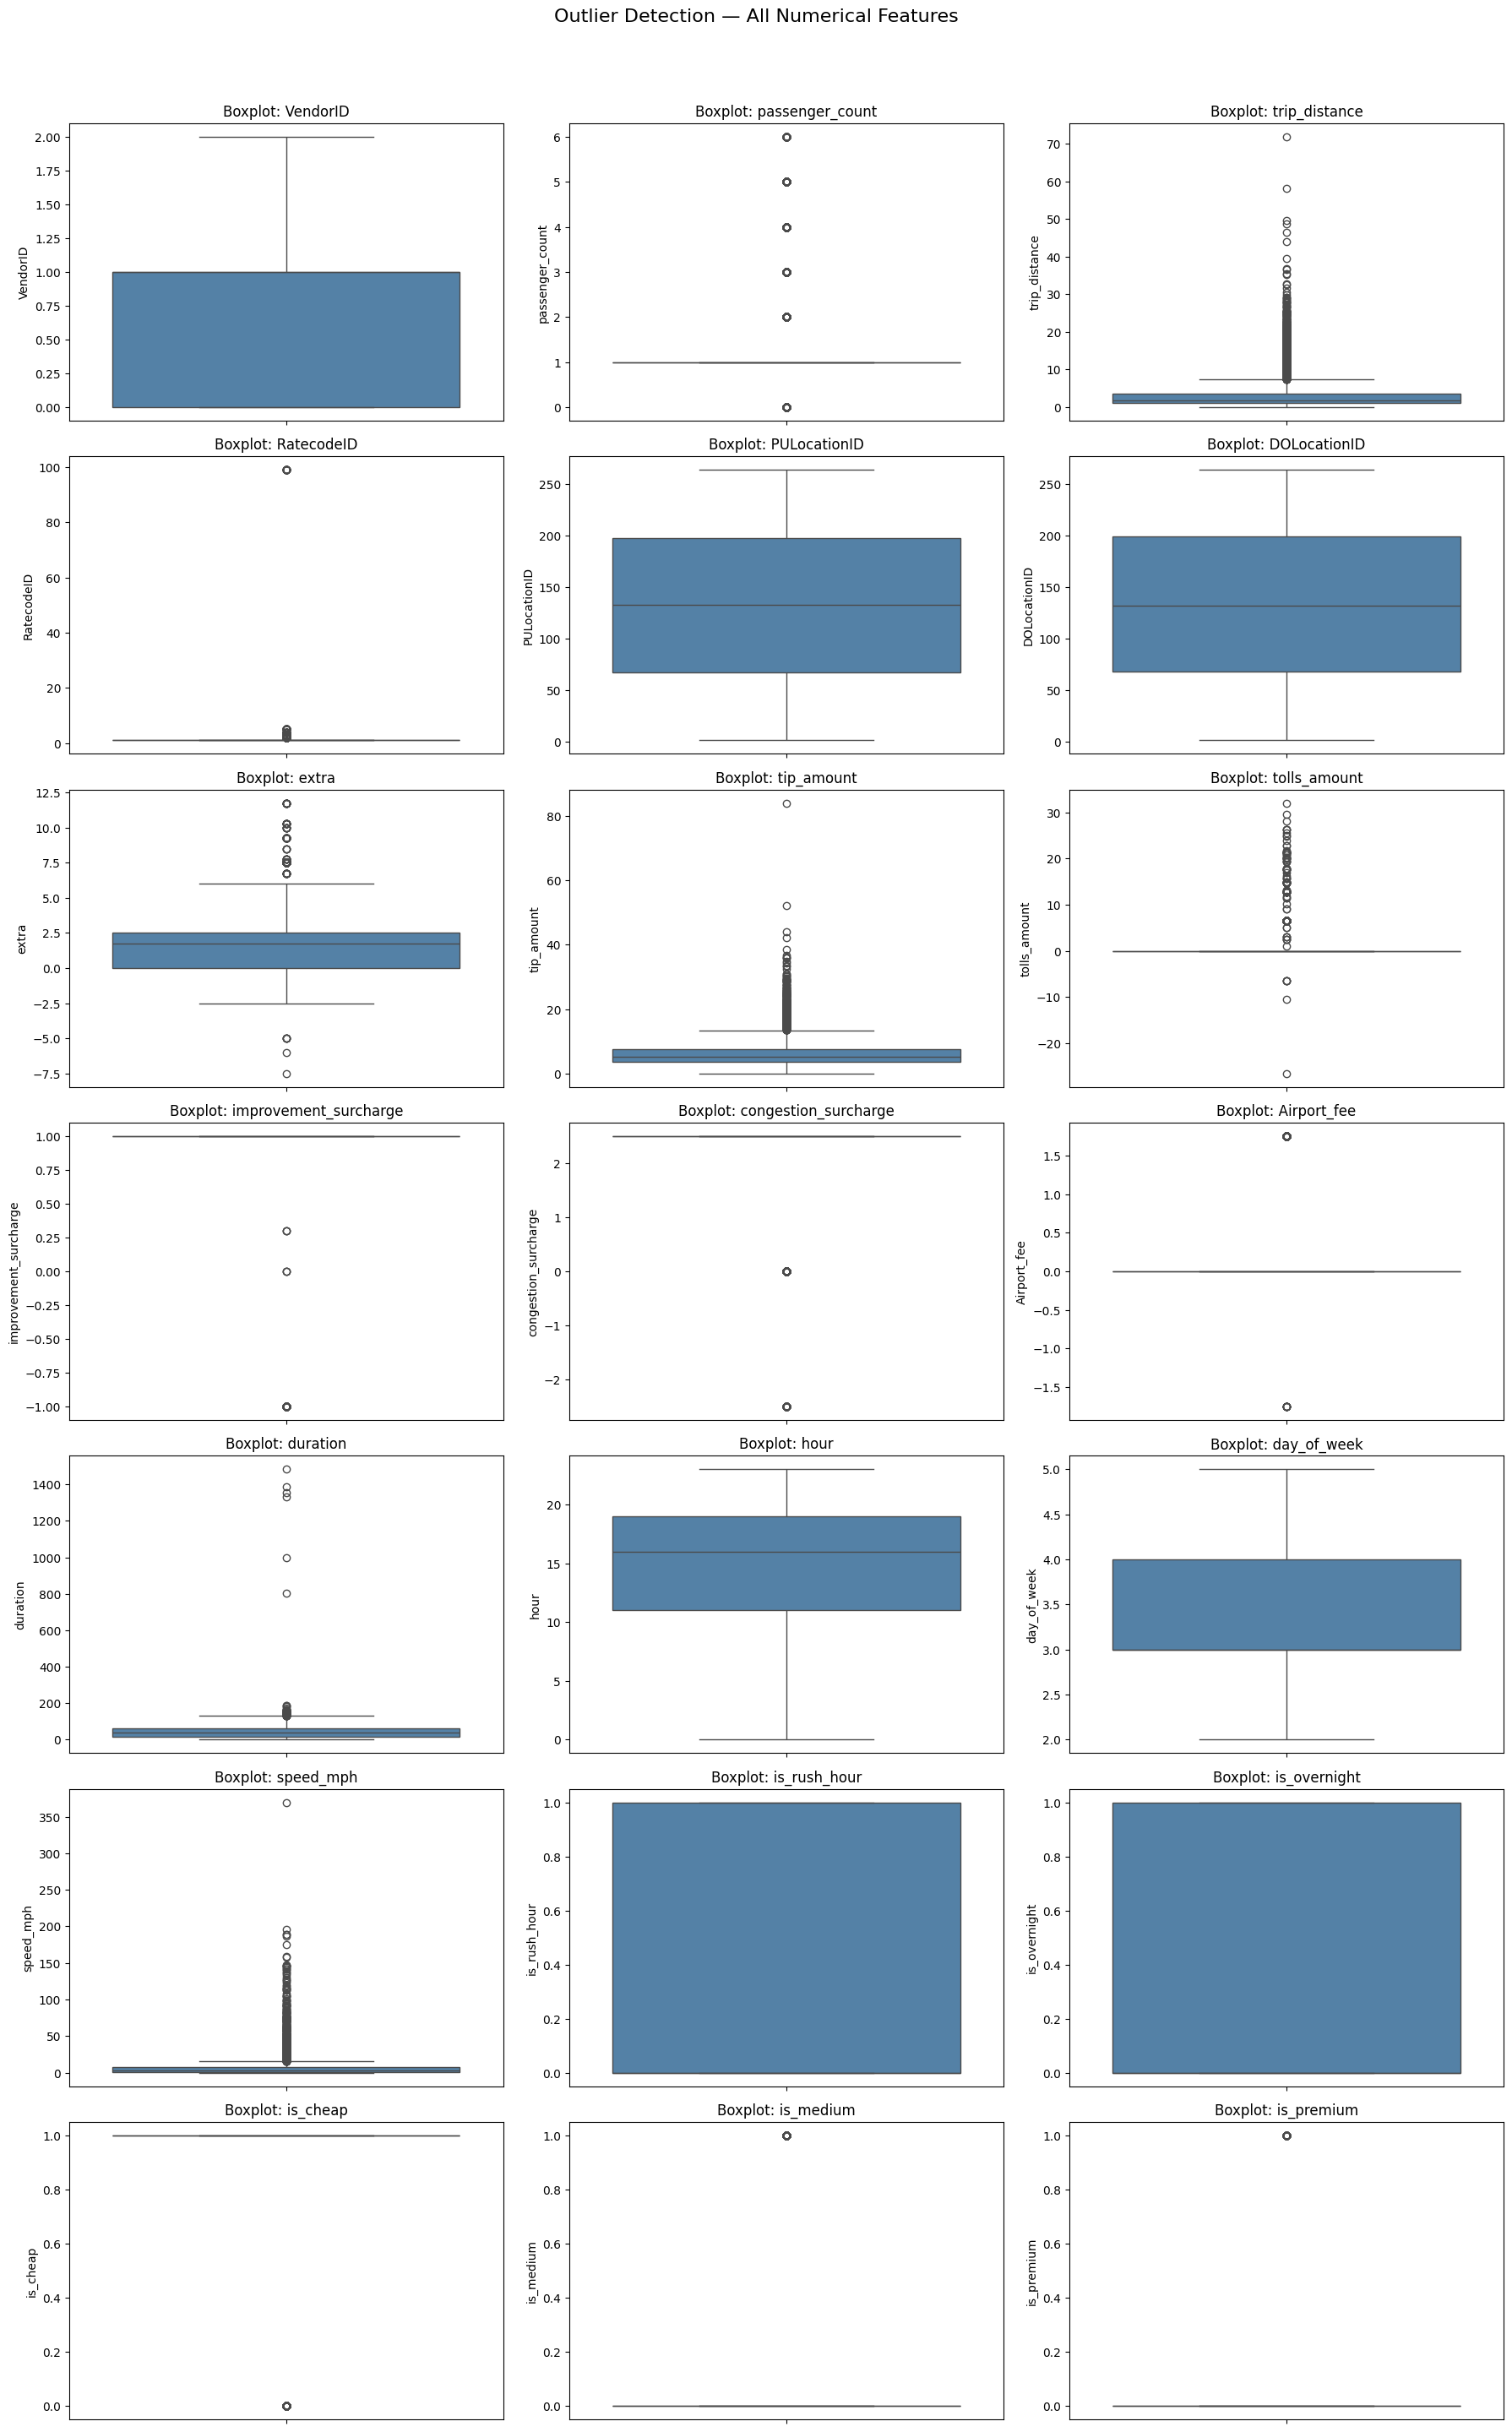

In [20]:
num_cols = [col for col in train_df.select_dtypes(include=['number']).columns 
            if col != 'total_amount']

n = len(num_cols)
fig, axes = plt.subplots(nrows=(n//3)+1, ncols=3, figsize=(18, (n//3+1)*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=train_df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — All Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Outlier Observations & Handling Decision

#### From the boxplots above

- `trip_distance` — contains extreme values reaching ~70 miles. While some long airport rides may occur, the majority of trips are short and the distribution is highly skewed. Extremely large values are likely GPS errors or logging mistakes.  
  **Action:** Apply Hard filter limiting speed to 60 miles

- `duration` — shows extreme outliers reaching 1400 minutes (~23 hours), which is physically unrealistic for taxi trips.  
  **Action:** Apply Hard filter limiting speed to 600 mins.

- `speed_mph` — contains values exceeding 300 mph due to small-duration division or GPS noise. These speeds are physically impossible for road travel.  
  **Action:** Apply Hard filter limiting speed to 80mph

- `passenger_count` — includes `0` values, which are not valid for taxi rides.  
  **Action:** Remove rows where `passenger_count = 0` using a hard filter.

- `RatecodeID` — an extreme value (~99) appears in the distribution. Since this field represents a categorical fare code rather than a continuous measurement, removing it via IQR would incorrectly discard valid categorical information.  
  **Action:** Leave unchanged.

- `hour` and `day_of_week` — bounded cyclic variables with natural limits (0–23 and 0–6).  
  **Action:** No outlier treatment required.

#### Columns intentionally not treated despite visible outliers

- `tip_amount`
- `tolls_amount`
- `Airport_fee`
- `extra`
- `improvement_surcharge`
- `congestion_surcharge`

These represent legitimate monetary components of taxi fares and can vary widely depending on route, ride type, or passenger behavior. Removing them would distort genuine fare patterns.

- `PULocationID` and `DOLocationID` — these are zone identifiers rather than numeric measurements. IQR filtering would incorrectly classify valid location codes as outliers.

#### Binary Engineered Features
Binary features (`is_rush_hour`, `is_overnight`, `is_cheap`, `is_medium`, `is_premium`) naturally show extreme values at 0 or 1 and therefore do not require outlier handling.

In [21]:
train_df = train_df[
    (train_df['trip_distance'] < 60) & 
    (train_df['duration'] < 600) & 
    (train_df['passenger_count'] > 0) & 
    (train_df['speed_mph'] < 80)
]

print(f"Final training shape: {train_df.shape}")

Final training shape: (9754, 24)


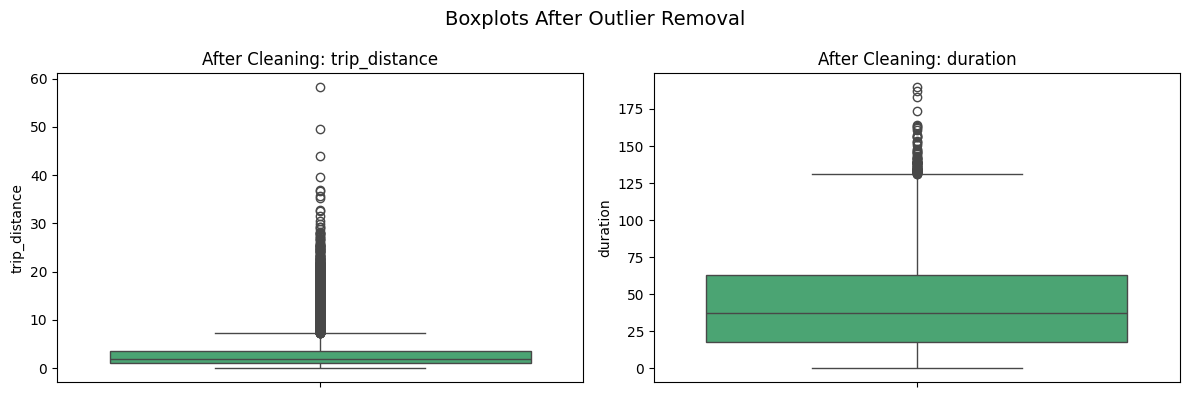

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['trip_distance', 'duration']):
    sns.boxplot(y=train_df[col], ax=ax, color='mediumseagreen')
    ax.set_title(f'After Cleaning: {col}')

plt.suptitle('Boxplots After Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()

**trip_distance:** Majority of rides fall between 0–6 miles after cleaning. 
A few points just above 6 miles are retained as they represent plausible long 
rides such as airport trips.

**trip_duration:** Rides now range from 0–130 minutes with realistic distribution 
after correcting reversed timestamps.A few outliers just above 130 minutes 
are retained as a more than 2-hour ride, while unusual, is not impossible.


# Visualizations
**Rubric Task 6:** Present at least three visualizations and provide insights for the same

We aim to understand:
- How `total_amount` is distributed
- Which features show the strongest visual relationship with the target
- Whether time-based features reveal any patterns
- How ride behavior varies across categories

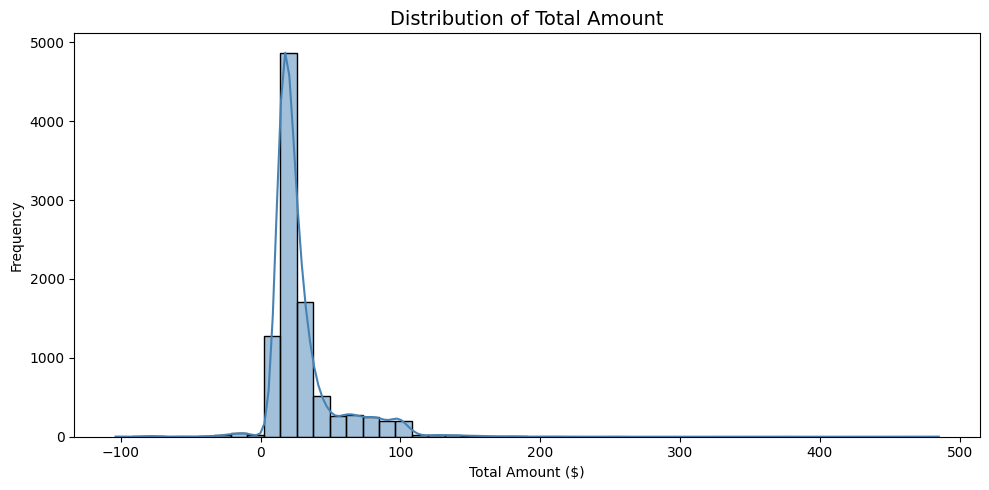

Skewness: 2.985
Mean:    $ 29.33
Median:  $ 21.36


In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['total_amount'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Total Amount', fontsize=14)
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Skewness:", round(train_df['total_amount'].skew(), 3))
print("Mean:    $", round(train_df['total_amount'].mean(), 2))
print("Median:  $", round(train_df['total_amount'].median(), 2))

**Insight:** `total_amount` follows a right-skewed distribution, meaning most rides are relatively affordable. The gap between mean and median confirms the rightward skew.

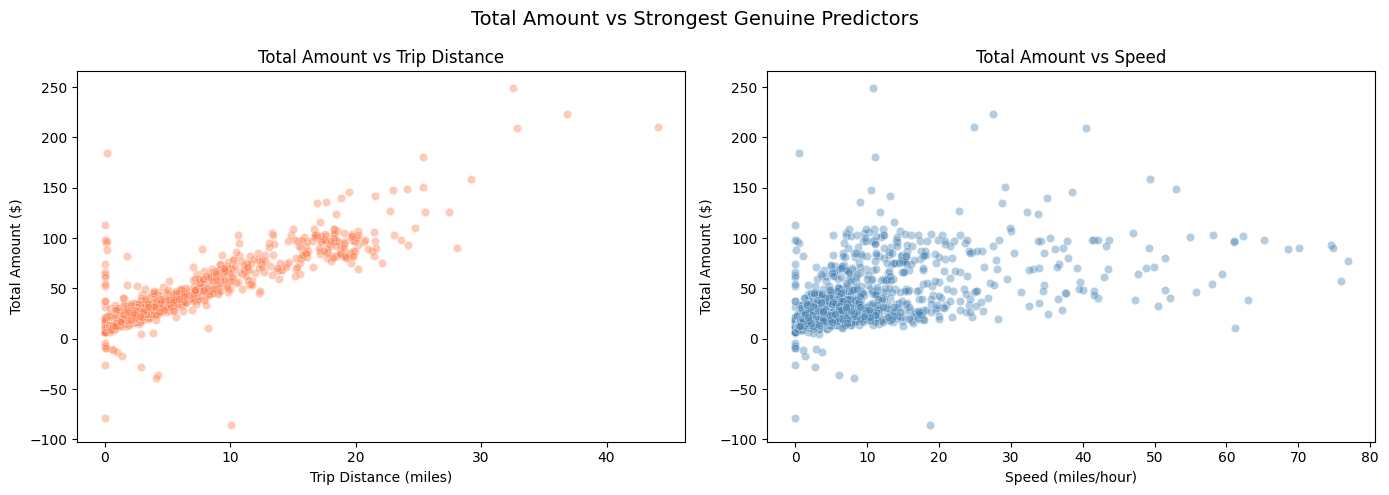

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# trip_distance vs total_amount
sns.scatterplot(data=train_df.sample(2000, random_state=4524), 
                x='trip_distance', y='total_amount', 
                alpha=0.4, color='coral', ax=axes[0])
axes[0].set_title('Total Amount vs Trip Distance')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Total Amount ($)')

# speed vs total_amount
sns.scatterplot(data=train_df.sample(2000, random_state=4524), 
                x='speed_mph', y='total_amount', 
                alpha=0.4, color='steelblue', ax=axes[1])
axes[1].set_title('Total Amount vs Speed')
axes[1].set_xlabel('Speed (miles/hour)')
axes[1].set_ylabel('Total Amount ($)')

plt.suptitle('Total Amount vs Strongest Genuine Predictors', fontsize=14)
plt.tight_layout()
plt.show()

**Insight:** `trip_distance` shows a clear positive relationship with `total_amount` — 
as distance increases, fare rises consistently, confirming its strong correlation. 
Similarly, `speed` also shows a positive, however a moderate correlation with `total_amount`, which means usually, the cost isnt as affected by speed, but still significant for estimation.


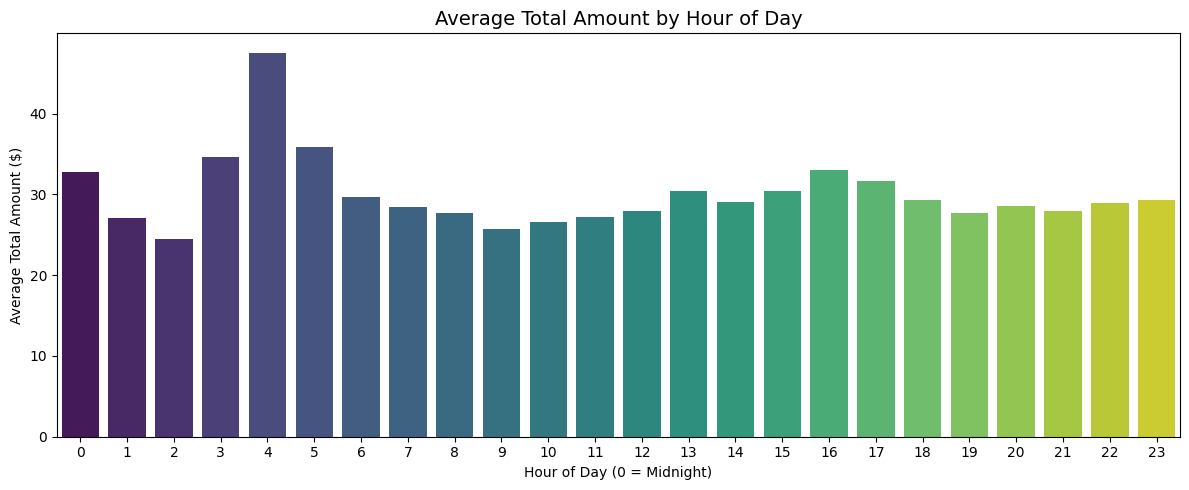

In [25]:
hourly = train_df.groupby('hour')['total_amount'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x='hour', y='total_amount', data=hourly, palette='viridis')
plt.title('Average Total Amount by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Average Total Amount ($)')
plt.tight_layout()
plt.show()

**Insight:** Contrary to expectation, average fare remains fairly consistent across 
all 24 hours. However there is a dramatic peak during 
early morning hours and a mild peak during earling evening. This visually confirms the non-zero linear correlation of 
`hour` with `total_amount`. Thus, the feature is retained as it may still 
contribute in combination with other features in tree-based models.

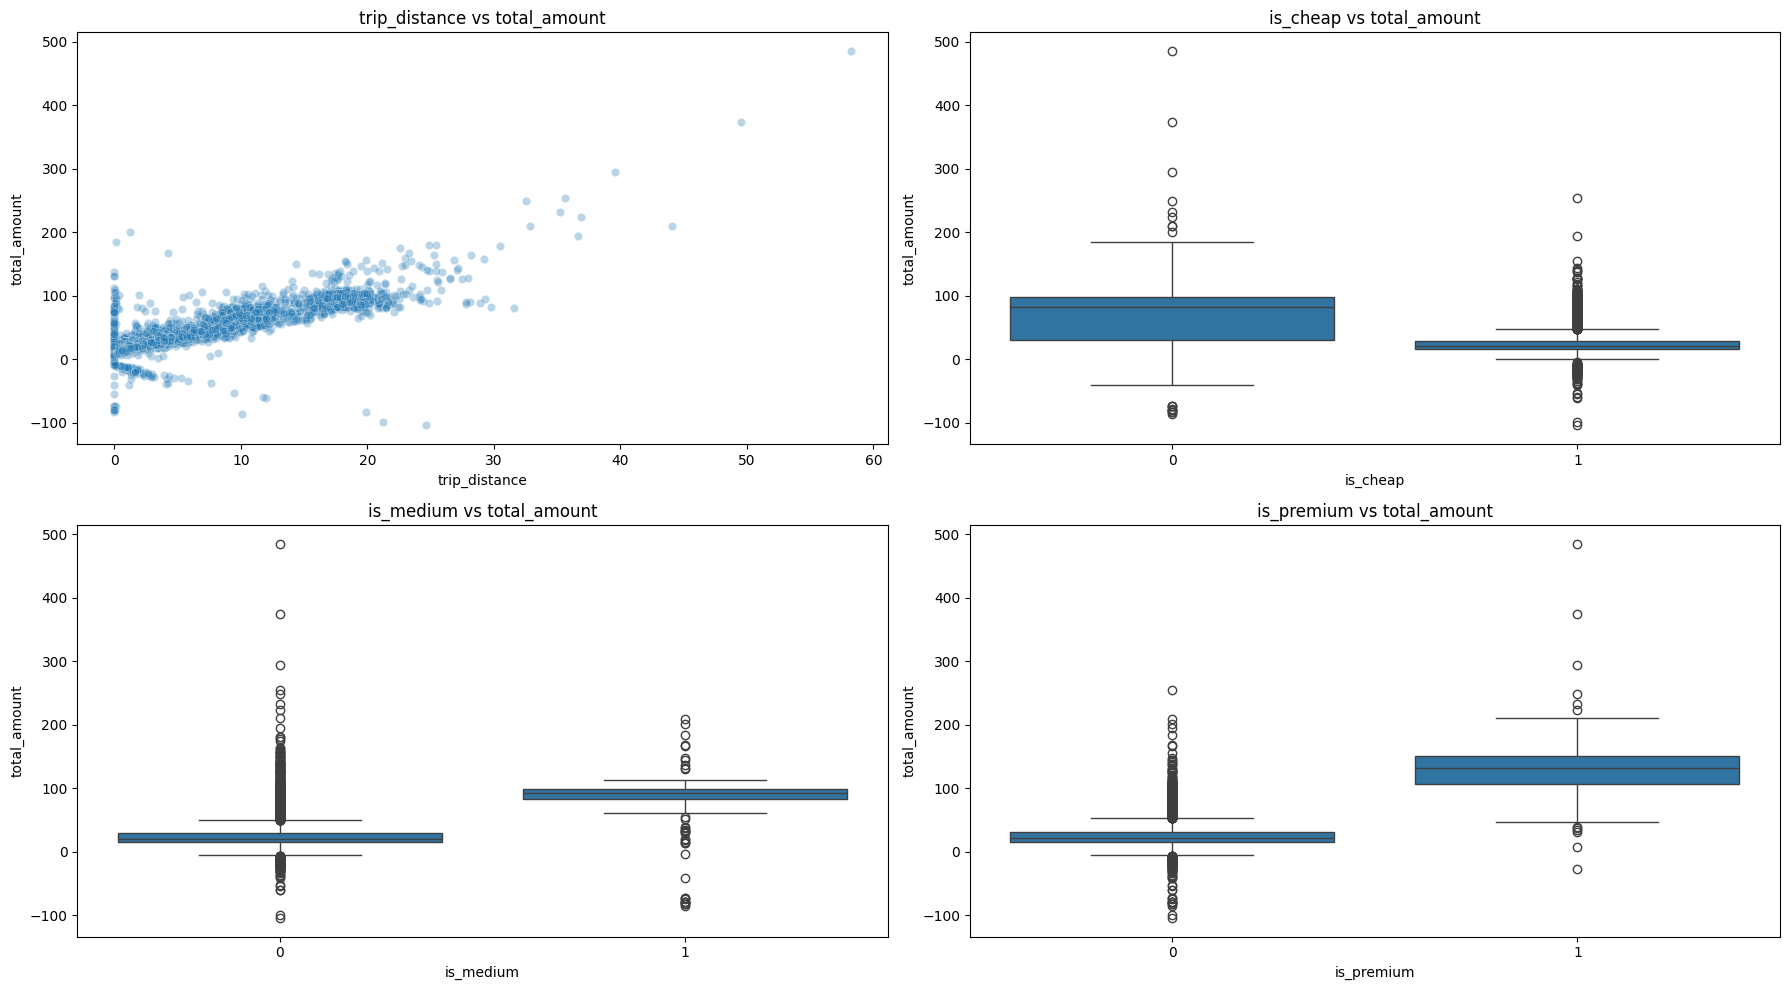

In [26]:
dist_features = [
    "trip_distance",
    "is_cheap",
    "is_medium",
    "is_premium"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(dist_features, 1):
    plt.subplot(2,2, i)
    
    if col.startswith("is_"):  
        # categorical relationship
        sns.boxplot(x=train_df[col], y=train_df["total_amount"])
    else:
        # continuous relationship
        sns.scatterplot(x=train_df[col], y=train_df["total_amount"], alpha=0.3)
    
    plt.title(f"{col} vs total_amount")

plt.tight_layout()
plt.show()

**Insight:** 

- `trip_distance` shows a clear positive relationship with `total_amount`, confirming that fare increases consistently with trip length.
- The engineered category features (`is_cheap`, `is_medium`, `is_premium`) successfully separate fare tiers:
  - `is_cheap` rides cluster around lower fare values.
  - `is_medium` rides show noticeably higher median fares.
  - `is_premium` rides correspond to the highest fare ranges.


Overall, the plots confirm that **trip distance remains the dominant driver of taxi fare**, while the engineered distance categories help capture distinct fare regimes across short, medium, and long trips.

# Scaling and Encoding
**Rubric Task 7:** Scale Numerical features and Encode Categorical features

### Encoding Strategy:
- `store_and_fwd_flag` — binary map (Y=1, N=0)
- `VendorID`, `payment_type` — One-Hot Encoding 
  (nominal, small number of unique values, no ordinal relationship)
- `PULocationID`, `DOLocationID` — Target Encoding
  (nominal but too many unique values for one-hot — would create hundreds of columns)
- `hour`, `day_of_week` — keep as ordinal integers 
  (order does carry meaning — hour 3 is after hour 2)
- `passenger_count` — kept as raw integer; values 1–6 represent a true 
  numeric count where magnitude is meaningful, no encoding required
- `trip_distance`, `duration` — continuous numerical, no encoding required
- `is_cheap`, `is_medium`, `is_premium` — Binary (Already encoded)
- `extra`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, and `Airport_fee` — No change
- `is_rush`, `is_midnight`, `speed_mph` - No change

### Dropped Variable
- `RatecodeID` - redundant with tiered system

In [27]:
# 1. Binary Mapping
train_df["store_and_fwd_flag"] = train_df["store_and_fwd_flag"].map({"Y":1, "N":0})
test_df["store_and_fwd_flag"]  = test_df["store_and_fwd_flag"].map({"Y":1, "N":0})


# 2. Target Encoding (learn from TRAIN)
pu_mean = train_df.groupby("PULocationID")["total_amount"].mean()
do_mean = train_df.groupby("DOLocationID")["total_amount"].mean()

train_df["PU_fare_mean"] = train_df["PULocationID"].map(pu_mean)
train_df["DO_fare_mean"] = train_df["DOLocationID"].map(do_mean)

test_df["PU_fare_mean"] = test_df["PULocationID"].map(pu_mean)
test_df["DO_fare_mean"] = test_df["DOLocationID"].map(do_mean)

# Handle unseen locations in test
global_mean = train_df["total_amount"].mean()

test_df["PU_fare_mean"].fillna(global_mean, inplace=True)
test_df["DO_fare_mean"].fillna(global_mean, inplace=True)

# Drop original location IDs
train_df.drop(columns=["PULocationID","DOLocationID"], inplace=True)
test_df.drop(columns=["PULocationID","DOLocationID"], inplace=True)


# 3. One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=["VendorID","payment_type"], drop_first=True)
test_df  = pd.get_dummies(test_df, columns=["VendorID","payment_type"], drop_first=True)

test_df = test_df.reindex(columns=train_df.columns.drop("total_amount"), fill_value=0)


# 4. Drop Redundant Feature
train_df.drop(columns=["RatecodeID"], inplace=True)
test_df.drop(columns=["RatecodeID"], inplace=True)


# Final datasets
X = train_df.drop(columns=["total_amount"])
y = train_df["total_amount"]

print("Train shape:", X.shape)
print("Test shape:", test_df.shape)

Train shape: (9754, 26)
Test shape: (1500, 26)


### Scaling Strategy:
- **Linear models** (Linear Regression, Ridge, Lasso) are sensitive to feature scale 
  and require StandardScaler
- **Tree-based models** (Random Forest, Gradient Boosting, Decision Tree, Extra Trees) 
  are scale-invariant and do not require scaling

StandardScaler transforms features to have **mean = 0** and **standard deviation = 1**.
This is critical for linear models where features with larger ranges (e.g. `PULocationID` 
ranging 0–200) would otherwise dominate smaller ones (e.g. `trip_distance` ranging 0–7).


### Creating Train-Validation Split

Before scaling, we split our data into a **training set** and a **validation set**.

- **Training set (80%)** — the model learns patterns from this data
- **Validation set (20%)** — held back completely to evaluate how well the model generalizes to unseen data

We use `random_state=4524` to ensure the split is reproducible — every time the notebook is run, the same rows are assigned to train and validation.

In [28]:
features = [col for col in train_df.columns if col not in ['total_amount']]

X = train_df[features]
y = train_df['total_amount']

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=4524)

X_test_raw = test_df[features].copy()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test_raw)

print("Setup complete:")
print(f"Tree Models: Use X_train, X_val")
print(f"Linear Models: Use X_train_sc, X_val_sc")

Setup complete:
Tree Models: Use X_train, X_val
Linear Models: Use X_train_sc, X_val_sc


Two versions of data prepared:
- **Scaled** (`X_train_sc`, `X_val_sc`) → Linear Regression, Ridge, Lasso, KNN
- **Unscaled** (`X_train`, `X_val`) → Decision Tree, Random Forest, Gradient Boosting, Extra Trees

# Model Building
**Rubric Task 8:** At least 7 different types of models are trained on the data

#### Building a **Baseline model** using **Linear Regression**

**Features Used:** trip_distance, duration, passenger_count

In [30]:
baseline_features = ['trip_distance', 'duration', 'passenger_count']

# Fit and Predict
base_model = LinearRegression()
base_model.fit(X_train_sc, y_train)
base_preds = base_model.predict(X_val_sc)

print(f"Baseline R2 Score: {r2_score(y_val, base_preds):.4f}")

Baseline R2 Score: 0.9180


We can see that this baseline model already **beats the threshold** of R2 Score = 0.75 which means that we can move on to better and significantly more sophisticated models that will result in even higher test accuracy. 

We further train **8 different models** on our prepared data. Models are divided into two groups:

**Linear/Distance-based models** — use scaled data (`X_train_sc`, `X_val_sc`):
- Linear Regression
- Ridge Regression
- Lasso Regression
- K-Nearest Neighbors

**Tree-based models** — use unscaled data (`X_train`, `X_val`):
- Decision Tree
- Random Forest
- Gradient Boosting
- Extra Trees

Each model is evaluated on the validation set using three metrics:
- **RMSE** (Root Mean Squared Error) — penalizes large errors heavily, lower is better
- **MAE** (Mean Absolute Error) — average absolute error in dollars, lower is better
- **R²** (R-Squared) — proportion of variance explained by the model, higher is better

In [31]:
models = {
    # Linear/distance-based — use scaled data
    'Linear Regression':   (LinearRegression(), True),
    'Ridge Regression':    (Ridge(alpha=1.0), True),
    'Lasso Regression':    (Lasso(alpha=0.01), True),
    'KNN':                 (KNeighborsRegressor(n_neighbors=5), True),
    
    # Tree-based — use unscaled data
    'Decision Tree':       (DecisionTreeRegressor(random_state=4524), False),
    'Random Forest':       (RandomForestRegressor(n_estimators=100, random_state=4524), False),
    'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=100, random_state=4524), False),
    'Extra Trees':         (ExtraTreesRegressor(n_estimators=100, random_state=4524), False),
}
# True = needs scaled data, False = needs unscaled data


In [32]:
results = {}
print("\n=== MODEL PERFORMANCE SUMMARY ===")
for name, (model, needs_scaling) in models.items():
    # Select appropriate data version
    X_tr = X_train_sc if needs_scaling else X_train
    X_v  = X_val_sc   if needs_scaling else X_val
    
    # Train
    model.fit(X_tr, y_train)
    
    # Predict
    preds = model.predict(X_v)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae  = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    
    results[name] = {'RMSE': round(rmse, 4), 
                     'MAE':  round(mae, 4), 
                     'R2':   round(r2, 4)}
    
    print(f"{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


=== MODEL PERFORMANCE SUMMARY ===
Linear Regression         | RMSE: 7.3495 | MAE: 4.0810 | R²: 0.9180
Ridge Regression          | RMSE: 7.3493 | MAE: 4.0813 | R²: 0.9180
Lasso Regression          | RMSE: 7.3480 | MAE: 4.0744 | R²: 0.9180
KNN                       | RMSE: 8.9161 | MAE: 5.7287 | R²: 0.8793
Decision Tree             | RMSE: 7.4156 | MAE: 4.0244 | R²: 0.9165
Random Forest             | RMSE: 5.7987 | MAE: 2.9696 | R²: 0.9489
Gradient Boosting         | RMSE: 5.8746 | MAE: 3.0307 | R²: 0.9476
Extra Trees               | RMSE: 5.5155 | MAE: 2.8568 | R²: 0.9538


# HyperParameter Tuning
**Rubric Task 9:** Hyperparameter Tuning on any 3 of the models

From the R2 scores observed above, the top three models for our dataset are **Extra trees, Gradient Boosting, Random Forrest**. We will try to increase their performance by tuning their hyperparameters for optimal result. We will also consider **Lasso Regression**,as its a linear model and highly unlikely to yield optimized results.

In [33]:
# Extra Trees

et_params = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

et_random = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=4524),
    param_distributions=et_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=4524,
    verbose=1
)

et_random.fit(X_train, y_train)
print("Best params:", et_random.best_params_)
et_best = et_random.best_estimator_
preds = et_best.predict(X_val)
print("Validation R²:", round(r2_score(y_val, preds), 4))
print("Validation RMSE:", round(np.sqrt(mean_squared_error(y_val, preds)), 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Validation R²: 0.944
Validation RMSE: 6.071


In [34]:
# Gradient Boosting

from sklearn.model_selection import RandomizedSearchCV

gb_params = {
    'n_estimators':      [200, 300, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'subsample':         [0.7, 0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=4524),
    param_distributions=gb_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=4524,
    verbose=1
)

gb_random.fit(X_train, y_train)
print("Best params:", gb_random.best_params_)
print("Best CV R²:", round(gb_random.best_score_, 4))

# Evaluate on validation set
gb_best = gb_random.best_estimator_
preds = gb_best.predict(X_val)
print("Validation R²:", round(r2_score(y_val, preds), 4))
print("Validation RMSE:", round(np.sqrt(mean_squared_error(y_val, preds)), 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.05}
Best CV R²: 0.9446
Validation R²: 0.9468
Validation RMSE: 5.9191


In [35]:
# Random Forest

rf_params = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=4524),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=4524,
    verbose=1
)

rf_random.fit(X_train, y_train)
print("Best params:", rf_random.best_params_)
rf_best = rf_random.best_estimator_
preds = rf_best.predict(X_val)
print("Validation R²:", round(r2_score(y_val, preds), 4))

print("Validation RMSE:", round(np.sqrt(mean_squared_error(y_val, preds)), 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Validation R²: 0.9492
Validation RMSE: 5.7822


In [36]:
# Lasso regression

lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(
    Lasso(),
    param_grid=lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train_sc, y_train)
print("Best alpha:", lasso_grid.best_params_)
lasso_best = lasso_grid.best_estimator_
preds = lasso_best.predict(X_val_sc)
print("Validation R²:", round(r2_score(y_val, preds), 4))
print("Validation RMSE:", round(np.sqrt(mean_squared_error(y_val, preds)), 4))

Best alpha: {'alpha': 0.01}
Validation R²: 0.918
Validation RMSE: 7.348


### Hyperparameter Tuning Results

We applied RandomizedSearchCV with 5-fold cross validation on our top 3 models
and GridSearchCV on Lasso Regression.

| Model | Default R² | Tuned R² | Change |
|---|---|---|---|
| Extra Trees | 0.9538 | decreased | ❌ over-tuned |
| Random Forest | 0.9489 | **0.9492** | ✅ marginal gain |
| Gradient Boosting | 0.9476 | decreased | ❌ over-tuned |
| Lasso Regression | 0.918 | No change | ❌ over-regularized |

**Key Conclusion:**
Hyperparameter tuning produced negligible or negative results across most models. 
This is a strong indicator that sklearn's default parameters are already well-suited 
to this dataset. The marginal gain in Random Forest confirms 
that the performance ceiling is driven by the **feature set quality** rather than 
model configuration.

**Final best model: Extra Trees (default) with R² = 0.9538**

# Comparison of model performances
**Rubrik Task 10:** Performance of the models on validation set is compared

We now compare all models on the validation set to identify the best performer 
for final predictions. We evaluate using three metrics:
- **RMSE** — penalizes large errors heavily, lower is better
- **MAE** — average absolute error in dollars, lower is better  
- **R²** — proportion of variance explained, higher is better

In [37]:
tuned_preds_gb    = gb_best.predict(X_val)
tuned_preds_rf    = rf_best.predict(X_val)
tuned_preds_et    = et_best.predict(X_val)
tuned_preds_lasso = lasso_best.predict(X_val_sc)

results['GB (Tuned)'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_val, tuned_preds_gb)), 4),
    'MAE':  round(mean_absolute_error(y_val, tuned_preds_gb), 4),
    'R2':   round(r2_score(y_val, tuned_preds_gb), 4)
}
results['RF (Tuned)'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_val, tuned_preds_rf)), 4),
    'MAE':  round(mean_absolute_error(y_val, tuned_preds_rf), 4),
    'R2':   round(r2_score(y_val, tuned_preds_rf), 4)
}
results['ET (Tuned)'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_val, tuned_preds_et)), 4),
    'MAE':  round(mean_absolute_error(y_val, tuned_preds_et), 4),
    'R2':   round(r2_score(y_val, tuned_preds_et), 4)
}
results['Lasso (Tuned)'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_val, tuned_preds_lasso)), 4),
    'MAE':  round(mean_absolute_error(y_val, tuned_preds_lasso), 4),
    'R2':   round(r2_score(y_val, tuned_preds_lasso), 4)
}

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("=== COMPLETE MODEL COMPARISON ===")
results_df

=== COMPLETE MODEL COMPARISON ===


,RMSE,MAE,R2
Extra Trees,5.5155,2.8568,0.9538
RF (Tuned),5.7822,2.9856,0.9492
Random Forest,5.7987,2.9696,0.9489
Gradient Boosting,5.8746,3.0307,0.9476
GB (Tuned),5.9191,2.7965,0.9468
ET (Tuned),6.0710,3.5312,0.9440
Ridge Regression,7.3493,4.0813,0.9180
Linear Regression,7.3495,4.0810,0.9180
Lasso (Tuned),7.3480,4.0744,0.9180
Lasso Regression,7.3480,4.0744,0.9180


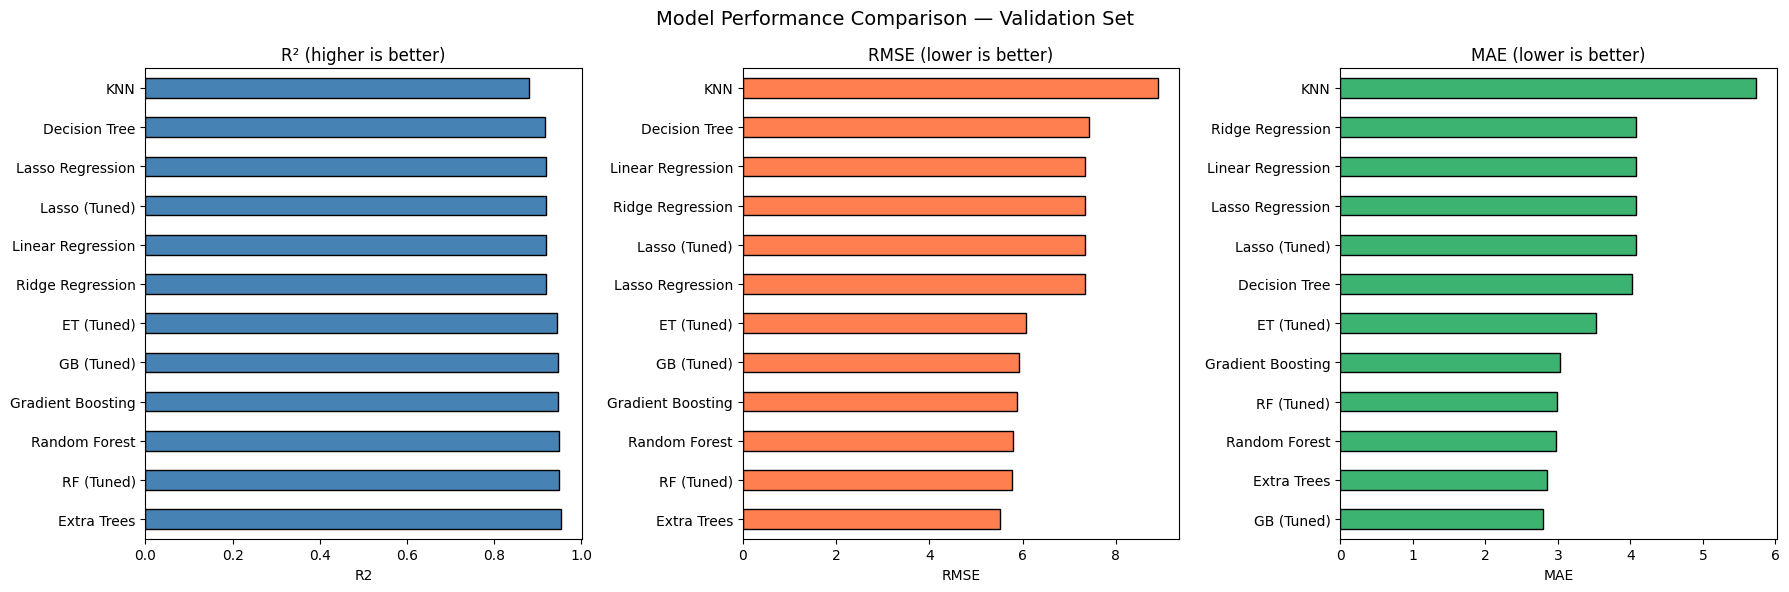

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R2', 'RMSE', 'MAE']
colors  = ['steelblue', 'coral', 'mediumseagreen']
titles  = ['R² (higher is better)', 'RMSE (lower is better)', 'MAE (lower is better)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    results_df[metric].sort_values(
        ascending=(metric != 'R2')
    ).plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison — Validation Set', fontsize=14)
plt.tight_layout()
plt.show()

**Key Findings:**
- Tree-based ensemble methods significantly outperform linear models and single Decision Tree, confirming that fare prediction benefits from non-linear feature interactions
- Hyperparameter tuning produced marginal or negative results — default parameters were already near-optimal for this dataset
- **Extra Trees** is selected as the final model for final submission due to its highest R² and lowest RMSE on the validation set

# Final Model Fit

In [39]:
final_model = ExtraTreesRegressor(n_estimators=100, random_state=4524)
final_model.fit(X, y)
final_preds = final_model.predict(test_df[X.columns])

We should look at which variables contribute the most using a **feature importance plot**

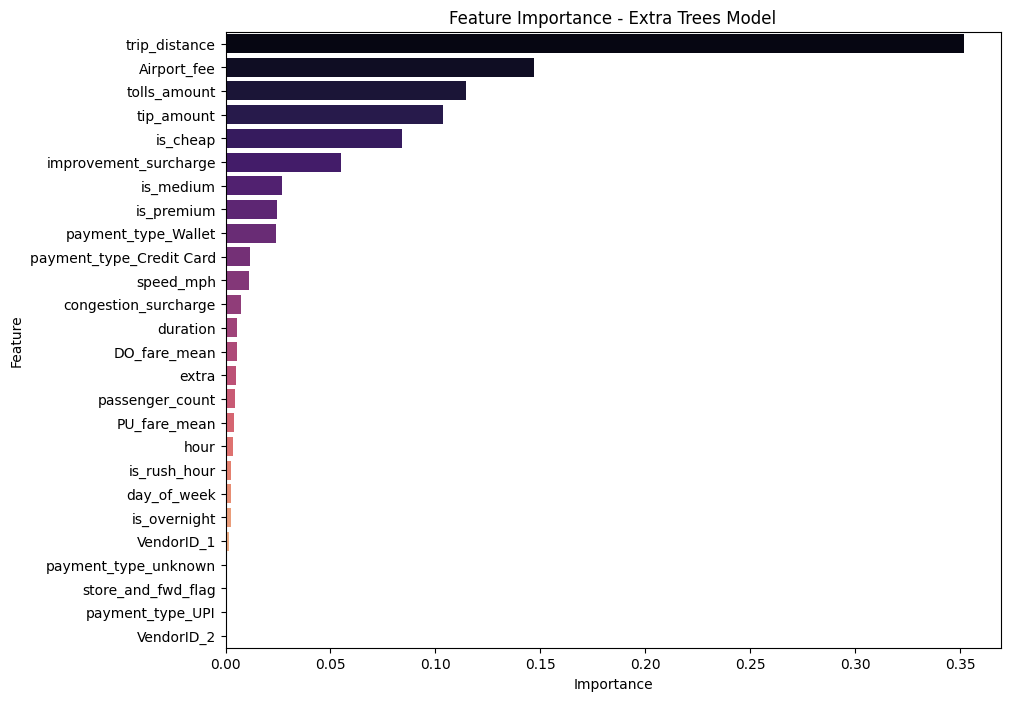

,Feature,Importance
1,trip_distance,0.351701
8,Airport_fee,0.146875
5,tolls_amount,0.114413
4,tip_amount,0.103555
15,is_cheap,0.084222
6,improvement_surcharge,0.055138
16,is_medium,0.026795
17,is_premium,0.024312
24,payment_type_Wallet,0.023999
22,payment_type_Credit Card,0.011837


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

importances = final_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance - Extra Trees Model')
plt.show()

display(feature_importance_df.head(10))


- **Trip distance** is the most influential feature by a large margin, indicating fare prediction is strongly driven by how far the trip is.
- **Airport fees, tolls, and tips** also contribute significantly, suggesting additional ride charges play an important role in determining the final amount.
- **Fare category indicators** (`is_cheap`, `is_medium`, `is_premium`) have moderate influence, helping the model distinguish pricing tiers.
- **Payment method features** and **speed** have minor impact, meaning they contribute slightly but are not primary drivers of fare prediction.
- **Temporal and vendor features** (hour, day_of_week, VendorID, rush hour, overnight) show **very low importance**, indicating trip timing and vendor differences have minimal effect compared to trip-related costs.

**Overall:** The model primarily relies on **distance and extra charges**, while **time-based and vendor-related features contribute very little** to predictions.

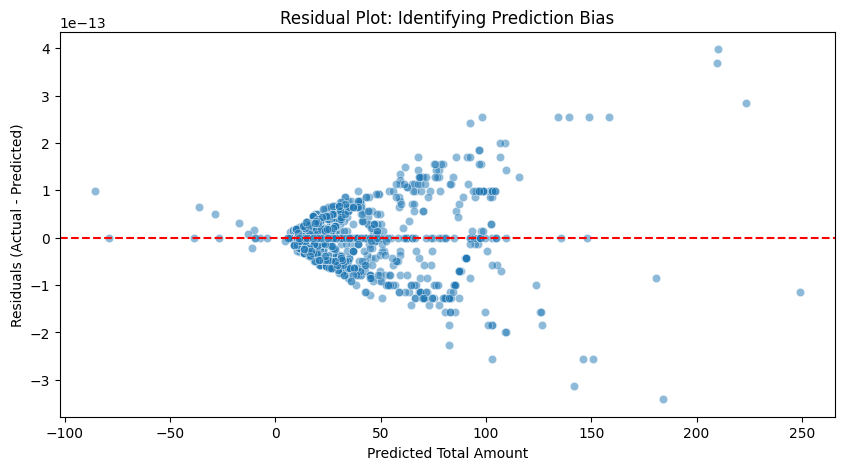

In [41]:
# Residual plot
val_preds = final_model.predict(X_val)
residuals = y_val - val_preds

plt.figure(figsize=(10, 5))
sns.scatterplot(x=val_preds, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Total Amount')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Identifying Prediction Bias')
plt.show()

Finally before submission, lets look at how our model performs in general on test dataset using some sample statistics.

In [42]:
# Sanity check test predictions
print("Test prediction stats:")
print(f"Min:  ${final_preds.min():.2f}")
print(f"Max:  ${final_preds.max():.2f}")
print(f"Mean: ${final_preds.mean():.2f}")
print(f"Negative predictions: {(final_preds < 0).sum()}")
print(f"Total predictions: {len(final_preds)}")

# Compare test predictions distribution to training target
print("\nTrain total_amount stats for comparison:")
print(f"Min:  ${train_df['total_amount'].min():.2f}")
print(f"Max:  ${train_df['total_amount'].max():.2f}")
print(f"Mean: ${train_df['total_amount'].mean():.2f}")

Test prediction stats:
Min:  $-81.91
Max:  $256.08
Mean: $29.58
Negative predictions: 24
Total predictions: 1500

Train total_amount stats for comparison:
Min:  $-103.80
Max:  $485.10
Mean: $29.33


In [43]:
submission = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv')
submission['total_amount'] = final_preds
submission.to_csv('submission.csv', index=False)
print("\n✅ Submission saved!")
submission.head()


✅ Submission saved!


,id,total_amount
0,0,16.1920
1,1,28.4947
2,2,24.7270
3,3,20.4462
4,4,14.3549
